In [34]:
import os
import json
import torch
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import torch.nn as nn
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform

from torchvision.ops import box_iou
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


In [2]:
print("Train files:", os.listdir("../data/data1/train")[:5])
print("Valid files:", os.listdir("../data/data1/valid")[:5])
print("Test files :", os.listdir("../data/data1/test")[:5])

Train files: ['P04926_jpg.rf.8003b351271dfc278f6c9f6a356edf85.jpg', 'P07751_jpg.rf.c7aba95a29d0e3e1b09a58ab82794d2a.jpg', 'P08694_jpg.rf.81e844a56d7d41bdd8d65d21bea82c76.jpg', 'P07129_jpg.rf.4ca8499256d96b60f7e1b5ed4cce3c4f.jpg', 'P04865_jpg.rf.3f5227a6da945e9ce7f2b63826bae8ac.jpg']
Valid files: ['P02780_jpg.rf.9f671b5ac83e2a88ed945e5478d820bc.jpg', 'P01200_jpg.rf.611b3b0ee087807418f1b33c51429b70.jpg', 'P08634_jpg.rf.32b7aceb288711f2f62d505b9bce7548.jpg', 'P00957_jpg.rf.c2a5f6ea5a2fe4ff3683e69736251bd9.jpg', 'P02777_jpg.rf.fa721fdc14d59869cafed6af46332d9d.jpg']
Test files : ['P03075_jpg.rf.e2bd7065a6fe004efd75d61d8cba1e6a.jpg', 'P00515_jpg.rf.42fe02f7e40d2805c5cee4133f6994da.jpg', 'P03373_jpg.rf.717700618a59e959e748d69d9ed322dc.jpg', 'P07440_jpg.rf.5f46b65f17e8ed996bc6ed2298d9a778.jpg', 'P03519_jpg.rf.4e4de1b18be86a42411310d8eddd8074.jpg']


In [3]:
class CocoImageDataset(Dataset):
    def __init__(self, root, split="train", transform=None):

        self.image_dir = os.path.join(root, split)
        ann_file = os.path.join(root, split, "_annotations.coco.json")

        with open(ann_file) as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_info = self.images[idx]
        path = os.path.join(self.image_dir, img_info["file_name"])

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


In [4]:
jepa_transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

In [5]:
root = "../data/data1"

train_dataset = CocoImageDataset(root, "train", jepa_transform)
valid_dataset = CocoImageDataset(root, "valid", jepa_transform)

print("Train images:", len(train_dataset))
print("Valid images:", len(valid_dataset))


Train images: 3303
Valid images: 312


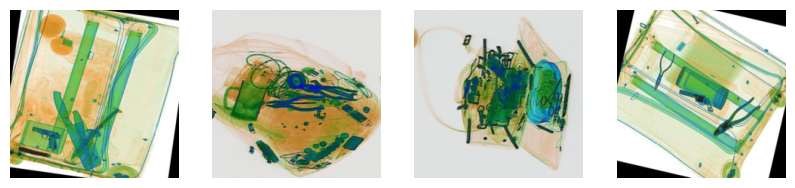

In [6]:
def show_samples(dataset):
    plt.figure(figsize=(10,5))

    for i in range(4):
        img = dataset[random.randint(0, len(dataset)-1)]
        img = img * 0.5 + 0.5       # unnormalize
        img = img.permute(1,2,0)

        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.axis("off")

show_samples(train_dataset)


In [7]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16)


In [8]:
class ViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model("vit_small_patch16_224", pretrained=False)
        self.dim = self.vit.embed_dim

    def forward(self, x):
        return self.vit.forward_features(x)


In [9]:
class Predictor(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return self.net(x)


In [10]:
def random_mask(x, mask_ratio=0.6):
    B, L, D = x.shape

    keep = int(L * (1 - mask_ratio))
    noise = torch.rand(B, L)

    ids = torch.argsort(noise, dim=1)

    ids_keep = ids[:, :keep]
    ids_mask = ids[:, keep:]

    return ids_keep, ids_mask


In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:


context_encoder = ViTEncoder().to(device)
target_encoder  = ViTEncoder().to(device)
predictor       = Predictor(context_encoder.dim).to(device)

optimizer = torch.optim.AdamW(
    list(context_encoder.parameters()) +
    list(predictor.parameters()),
    lr=1e-4
)

mse = nn.MSELoss()

for epoch in range(5):
    for imgs in train_loader:

        imgs = imgs.to(device)

        feats = context_encoder(imgs)

        ids_keep, ids_mask = random_mask(feats)

        context = torch.gather(
            feats, 1,
            ids_keep.unsqueeze(-1).repeat(1,1,feats.size(-1))
        )

        with torch.no_grad():
            target = target_encoder(imgs)

        pred = predictor(context.mean(1))
        tgt  = target.mean(1)

        loss = mse(pred, tgt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} Loss: {loss.item():.4f}")


Epoch 0 Loss: 0.0099
Epoch 1 Loss: 0.0046
Epoch 2 Loss: 0.0032
Epoch 3 Loss: 0.0031
Epoch 4 Loss: 0.0018


In [12]:
torch.save(context_encoder.state_dict(), "jepa_backbone.pth")
print("Backbone saved!")


Backbone saved!


In [21]:
class CocoDetectionDataset(Dataset):
    def __init__(self, root, split, transform=None):

        self.image_dir = os.path.join(root, split)
        ann_file = os.path.join(root, split, "_annotations.coco.json")

        with open(ann_file) as f:
            coco = json.load(f)

        self.images = coco["images"]

        self.ann = {}
        for a in coco["annotations"]:
            self.ann.setdefault(a["image_id"], []).append(a)

        self.transform = transform

    def __getitem__(self, idx):

        img_info = self.images[idx]
        img = Image.open(os.path.join(self.image_dir, img_info["file_name"])).convert("RGB")

        anns = self.ann.get(img_info["id"], [])

        boxes, labels = [], []

        for a in anns:
            x,y,w,h = a["bbox"]
            boxes.append([x,y,x+w,y+h])
            labels.append(a["category_id"])
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(img_info["id"])
        }

        if self.transform:
            img = self.transform(img)

        return img, target

    def __len__(self):
        return len(self.images)


In [22]:
det_train = CocoDetectionDataset(root, "train", jepa_transform)

det_loader = DataLoader(
    det_train,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

In [23]:
class JEPABackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ViTEncoder()
        self.encoder.load_state_dict(torch.load("jepa_backbone.pth"))
        self.out_channels = self.encoder.dim

    def forward(self, x):
        feat = self.encoder(x)        # [B, L, D]

        B, L, D = feat.shape

        # If CLS token exists, remove it
        if L == 197:
            feat = feat[:, 1:, :]     # remove CLS
            L = 196

        # Compute spatial dimension dynamically
        H = W = int(L ** 0.5)

        feat = feat.permute(0, 2, 1).contiguous().view(B, D, H, W)

        return {"0": feat}


In [24]:
# 1. Define anchor generator for ONE feature map
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

# 2. Create a fresh backbone
backbone = JEPABackbone()

# 3. Create a NEW model instance
model = FasterRCNN(
    backbone,
    num_classes = 7,     # from previous step
    rpn_anchor_generator = anchor_generator
).to(device)

# 4. Override transform (still required)
model.transform = GeneralizedRCNNTransform(
    min_size=224,
    max_size=224,
    image_mean=[0.5,0.5,0.5],
    image_std=[0.5,0.5,0.5]
)

optim = torch.optim.AdamW(model.parameters(), lr=1e-4)


In [25]:
images, targets = next(iter(det_loader))

processed = model.transform(images, targets)
print("After transform size:", processed[0].tensors.shape)


After transform size: torch.Size([4, 3, 224, 224])


In [26]:
x = images[0].unsqueeze(0).to(device)
print("Input to backbone:", x.shape)

feat = model.backbone(x)
print("Backbone output:", feat["0"].shape)


Input to backbone: torch.Size([1, 3, 224, 224])
Backbone output: torch.Size([1, 384, 14, 14])


In [27]:
print(model.rpn.anchor_generator)

AnchorGenerator()


In [28]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    image_count = 0

    for images, targets in det_loader:

        batch_size = len(images)
        image_count += batch_size

        images = [i.to(device) for i in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optim.zero_grad()
        loss.backward()
        optim.step()

        running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Images Processed: {image_count} | "
              f"Batch Loss: {loss.item():.4f}")

    avg_loss = running_loss / image_count
    print(f"\nEpoch {epoch+1} Completed | "
          f"Total Images: {image_count} | "
          f"Average Loss: {avg_loss:.4f}\n")


Epoch 1/10 | Images Processed: 4 | Batch Loss: 2.5835
Epoch 1/10 | Images Processed: 8 | Batch Loss: 0.9171
Epoch 1/10 | Images Processed: 12 | Batch Loss: 0.7101
Epoch 1/10 | Images Processed: 16 | Batch Loss: 0.5715
Epoch 1/10 | Images Processed: 20 | Batch Loss: 0.5827
Epoch 1/10 | Images Processed: 24 | Batch Loss: 0.5909
Epoch 1/10 | Images Processed: 28 | Batch Loss: 0.6790
Epoch 1/10 | Images Processed: 32 | Batch Loss: 0.7177
Epoch 1/10 | Images Processed: 36 | Batch Loss: 0.5495
Epoch 1/10 | Images Processed: 40 | Batch Loss: 0.4478
Epoch 1/10 | Images Processed: 44 | Batch Loss: 0.2805
Epoch 1/10 | Images Processed: 48 | Batch Loss: 0.5120
Epoch 1/10 | Images Processed: 52 | Batch Loss: 0.2303
Epoch 1/10 | Images Processed: 56 | Batch Loss: 0.5457
Epoch 1/10 | Images Processed: 60 | Batch Loss: 0.1970
Epoch 1/10 | Images Processed: 64 | Batch Loss: 0.2810
Epoch 1/10 | Images Processed: 68 | Batch Loss: 0.2299
Epoch 1/10 | Images Processed: 72 | Batch Loss: 0.2298
Epoch 1/10 |

In [29]:
test_dataset = CocoDetectionDataset(root, "test", transform=jepa_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

print("Test images:", len(test_dataset))


Test images: 156


In [30]:
torch.save(model.state_dict(), "jepa_fasterrcnn.pth")

In [31]:
backbone = JEPABackbone()

model = FasterRCNN(
    backbone,
    num_classes = 7,
    rpn_anchor_generator = anchor_generator
).to(device)

# override transform again
model.transform = GeneralizedRCNNTransform(
    min_size=224,
    max_size=224,
    image_mean=[0.5,0.5,0.5],
    image_std=[0.5,0.5,0.5]
)

model.load_state_dict(torch.load("jepa_fasterrcnn.pth"))
model.eval()

print("Model loaded for evaluation")


Model loaded for evaluation


In [35]:
gt_coco = COCO("../data/data1/test/_annotations.coco.json")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [40]:
results = []

with torch.no_grad():

    for images, targets in test_loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        for i, output in enumerate(outputs):

            img_id = img_id = int(targets[i]["image_id"])

            boxes = output["boxes"].cpu().numpy()
            scores = output["scores"].cpu().numpy()
            labels = output["labels"].cpu().numpy()

            for b, s, l in zip(boxes, scores, labels):

                results.append({
                    "image_id": int(img_id),
                    "category_id": int(l - 1),
                    "bbox": [
                        float(b[0]),
                        float(b[1]),
                        float(b[2]-b[0]),
                        float(b[3]-b[1])
                    ],
                    "score": float(s)
                })


In [41]:
import json

# save predictions temporarily
with open("predictions.json", "w") as f:
    json.dump(results, f)

pred_coco = gt_coco.loadRes("predictions.json")

coco_eval = COCOeval(gt_coco, pred_coco, "bbox")

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

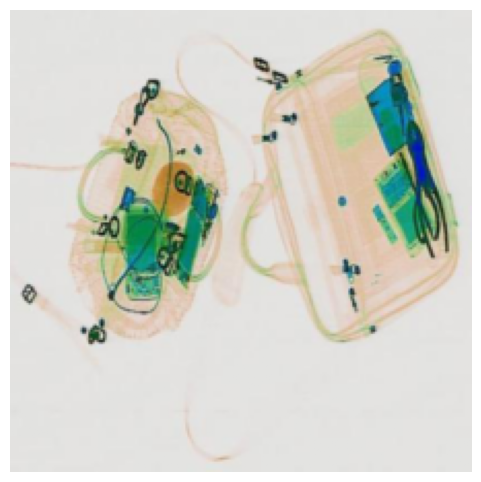

In [38]:
import matplotlib.pyplot as plt

def show_prediction(idx):

    img, target = test_dataset[idx]
    img_t = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model([img_t[0]])[0]

    img_vis = img * 0.5 + 0.5
    img_vis = img_vis.permute(1,2,0)

    plt.figure(figsize=(6,6))
    plt.imshow(img_vis)

    boxes = pred["boxes"].cpu()
    scores = pred["scores"].cpu()

    for b, s in zip(boxes, scores):
        if s > 0.5:
            x1,y1,x2,y2 = b
            plt.gca().add_patch(
                plt.Rectangle((x1,y1), x2-x1, y2-y1,
                              fill=False, color='red', linewidth=2)
            )

    plt.axis("off")
    plt.show()

show_prediction(0)


In [39]:
print("Total predictions generated:", len(results))


Total predictions generated: 1361


In [42]:
img_id = targets[i]["image_id"] if "image_id" in targets[i] else i


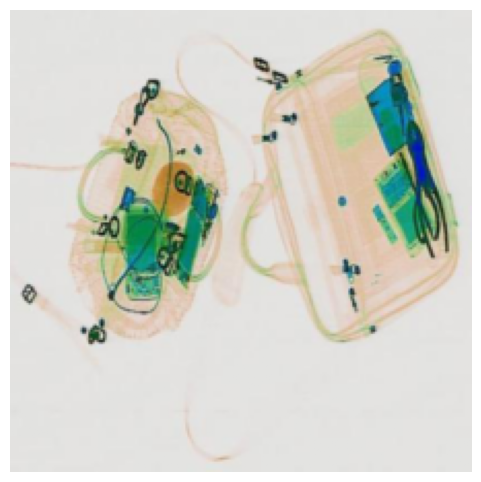

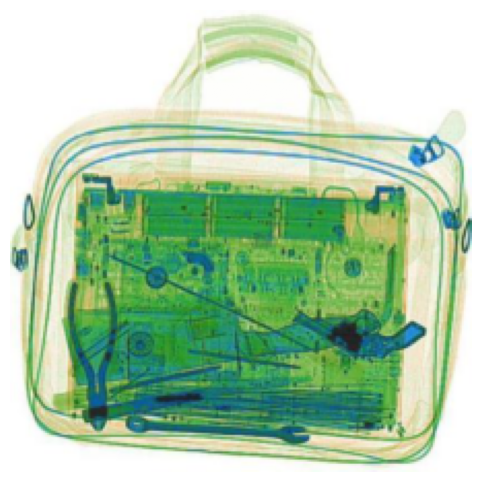

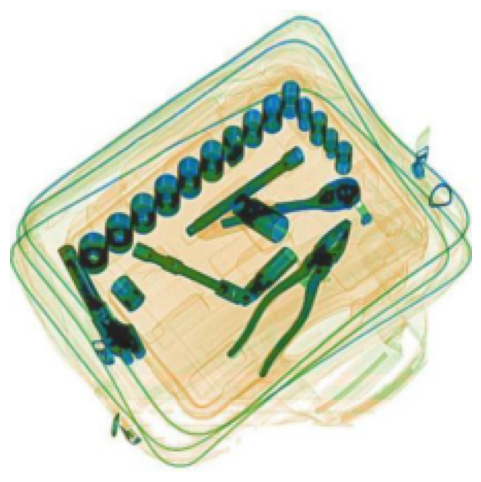

In [43]:
show_prediction(0)
show_prediction(1)
show_prediction(2)


In [44]:
print("Predictions:", len(results))

print("Sample prediction entry:", results[0])

print("Ground truth categories:", [c["id"] for c in gt_coco.cats.values()])


Predictions: 1361
Sample prediction entry: {'image_id': 0, 'category_id': 3, 'bbox': [222.81578063964844, 218.85252380371094, 1.179473876953125, 5.11968994140625], 'score': 0.052628546953201294}
Ground truth categories: [0, 1, 2, 3, 4, 5]
